# Factores de Riesgo Asociados a Enfermedad Cardíaca (BRFSS 2022)
### Proyecto Final — Data Experience

**Fuente de datos:** *Indicators of Heart Disease (2022 Update)* — Behavioral Risk Factor Surveillance System (BRFSS), CDC (Kaggle).

In [ ]:
from google.colab import files

# Subir la base de datos
uploaded = files.upload()          #Es un poco demorado, la base de datos es muy pesada

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)                                      #Importar librerias y declarar variales

ARCHIVO = 'Base de datos.csv'
df = pd.read_csv(ARCHIVO)
print('Filas:', df.shape[0], '| Columnas:', df.shape[1])
df.head()

Filas: 445132 | Columnas: 40


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",Age 80 or older,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 55 to 59,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",NaN,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 40 to 44,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## 3. Comprensión del conjunto de datos

primer revisamos la estructura general: tipos de dato, resumen estadístico y significado de cada variable.


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [103]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,445132,54,Washington,26152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,445132,2,Female,235893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GeneralHealth,443934,5,Very good,148444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealthDays,434205.0,NaN,NaN,NaN,4.347919,8.688912,0.0,0.0,0.0,3.0,30.0
MentalHealthDays,436065.0,NaN,NaN,NaN,4.382649,8.387475,0.0,0.0,0.0,5.0,30.0
LastCheckupTime,436824,4,Within past year (anytime less than 12 months ...,350944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalActivities,444039,2,Yes,337559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SleepHours,439679.0,NaN,NaN,NaN,7.022983,1.502425,1.0,6.0,7.0,8.0,24.0
RemovedTeeth,433772,4,None of them,233455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HadHeartAttack,442067,2,No,416959,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Diccionario de variables (resumen)

| Variable | Tipo | Descripción |
|---|---|---|
| State | Categórica | Estado de EE. UU. donde vive el encuestado |
| Sex | Categórica binaria | Sexo biológico (Male / Female) |
| GeneralHealth | Categórica ordinal | Percepción propia de salud general (Poor → Excellent) |
| PhysicalHealthDays | Numérica (0–30) | Días en el último mes con mala salud física |
| MentalHealthDays | Numérica (0–30) | Días en el último mes con mala salud mental |
| LastCheckupTime | Categórica | Hace cuánto fue el último chequeo médico |
| PhysicalActivities | Categórica binaria | Si hizo actividad física en el último mes |
| SleepHours | Numérica | Horas de sueño promedio por noche |
| SmokerStatus | Categórica | Estado de fumador (nunca, actual, exfumador) |
| ECigaretteUsage | Categórica | Uso de cigarrillo electrónico |
| HadHeartAttack / HadAngina / HadStroke / HadAsthma / HadSkinCancer / HadCOPD / HadDepressiveDisorder / HadKidneyDisease / HadArthritis | Categóricas binarias | Antecedentes clínicos autoreportados (Yes/No) |
| HadDiabetes | Categórica (4 niveles) | Antecedente de diabetes (incluye prediabetes / gestacional) |
| RaceEthnicityCategory | Categórica | Grupo étnico/racial |
| AgeCategory | Categórica ordinal | Rango de edad (13 categorías de 5 años) |
| HeightInMeters / WeightInKilograms / BMI | Numéricas | Estatura, peso e índice de masa corporal |
| AlcoholDrinkers | Categórica binaria | Consumo de alcohol |
| ChestScan / HIVTesting / FluVaxLast12 / PneumoVaxEver / TetanusLast10Tdap / HighRiskLastYear / CovidPos | Categóricas | Tamizajes y antecedentes de salud pública (preguntas opcionales de la encuesta, con más datos faltantes) |
| Difficulty* / DeafOrHardOfHearing / BlindOrVisionDifficulty | Categóricas binarias | Dificultades funcionales autoreportadas |

**Tamaño y forma:** 445.132 filas × 40 columnas, mezcla de variables numéricas continuas y categóricas (binarias y multiclase).


## 4. Limpieza y preparación de los datos

Se sigue el orden:
(1) nombres de columnas
(2) duplicados exactos
(3) texto (espacios/mayúsculas)
(4) categorías equivalentes
(5) valores imposibles
(6) valores faltantes al final.
Se trabaja siempre sobre una variable nueva o el propio `df` documentando cada paso


### 4.1 · Nombres de columnas

In [104]:
# Verificacion: espacios, mayusculas raras, caracteres especiales
print(df.columns.tolist())
df.columns = df.columns.str.strip()  # defensivo, por si acaso
print('\nNombres de columnas OK, no se requieren cambios adicionales.')

['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']

Nombres de columnas OK, no se requieren cambios adicionales.


### 4.2 · Duplicados exactos

Se cuentan los duplicados exactos (todas las columnas iguales) y se eliminan. En este punto no se excluye ninguna columna (como `id`) porque el dataset no trae identificador único.


In [105]:
duplicados_exactos = df.duplicated().sum()
print('Duplicados exactos encontrados:', duplicados_exactos)

df = df.drop_duplicates().reset_index(drop=True)
print('Filas despues de quitar duplicados:', df.shape[0])

Duplicados exactos encontrados: 157
Filas despues de quitar duplicados: 444975


### 4.3 · Texto: espacios y mayúsculas

Se revisa si las columnas de texto traen espacios sobrantes al inicio/final

In [106]:
columnas_texto = df.select_dtypes(include='object').columns
cambios = 0
for col in columnas_texto:
    original = df[col].copy()
    df[col] = df[col].str.strip()
    cambios += ((original != df[col]) & original.notna() & df[col].notna()).sum()

print('Valores de texto con espacios corregidos:', cambios)
print('(El archivo del CDC ya viene bien formateado; este paso queda como control de calidad.)')

Valores de texto con espacios corregidos: 0
(El archivo del CDC ya viene bien formateado; este paso queda como control de calidad.)


### 4.4 · Categorías equivalentes

Se revisan los valores únicos de cada columna categórica para detectar variantes de la misma categoría pero escritas diferente


In [107]:
for col in columnas_texto:
    n_unicos = df[col].nunique(dropna=True)
    if n_unicos <= 15:
        print(f'{col} ({n_unicos} categorias):', sorted(df[col].dropna().unique().tolist()))

Sex (2 categorias): ['Female', 'Male']
GeneralHealth (5 categorias): ['Excellent', 'Fair', 'Good', 'Poor', 'Very good']
LastCheckupTime (4 categorias): ['5 or more years ago', 'Within past 2 years (1 year but less than 2 years ago)', 'Within past 5 years (2 years but less than 5 years ago)', 'Within past year (anytime less than 12 months ago)']
PhysicalActivities (2 categorias): ['No', 'Yes']
RemovedTeeth (4 categorias): ['1 to 5', '6 or more, but not all', 'All', 'None of them']
HadHeartAttack (2 categorias): ['No', 'Yes']
HadAngina (2 categorias): ['No', 'Yes']
HadStroke (2 categorias): ['No', 'Yes']
HadAsthma (2 categorias): ['No', 'Yes']
HadSkinCancer (2 categorias): ['No', 'Yes']
HadCOPD (2 categorias): ['No', 'Yes']
HadDepressiveDisorder (2 categorias): ['No', 'Yes']
HadKidneyDisease (2 categorias): ['No', 'Yes']
HadArthritis (2 categorias): ['No', 'Yes']
HadDiabetes (4 categorias): ['No', 'No, pre-diabetes or borderline diabetes', 'Yes', 'Yes, but only during pregnancy (female)'

**Verificación:** al revisar los valores únicos de todas las variables categóricas no se encontraron variantes equivalentes de una misma categoría entoces no se necesitan reemplazos.

### 4.5 · Valores imposibles

Se definen rangos válidos para las variables numéricas continuas según su significado real (por ejemplo, `PhysicalHealthDays` no puede ser negativo ni mayor a 30, porque la pregunta original es "¿en cuántos de los últimos 30 días...?"). Los valores fuera de rango se van descartando **como dato faltante** (NaN), no se recorta la fila completa.


In [108]:
rangos_validos = {
    'PhysicalHealthDays': (0, 30),
    'MentalHealthDays':   (0, 30),
    'SleepHours':         (1, 24),
    'HeightInMeters':     (0.9, 2.3),
    'WeightInKilograms':  (20, 300),
    'BMI':                (10, 100),
}

reporte_imposibles = []
for col, (lo, hi) in rangos_validos.items():
    mask = (df[col] < lo) | (df[col] > hi)
    reporte_imposibles.append({'Variable': col, 'Rango valido': f'[{lo}, {hi}]', 'Valores imposibles': mask.sum()})
    df.loc[mask, col] = np.nan

pd.DataFrame(reporte_imposibles)

,Variable,Rango valido,Valores imposibles
0,PhysicalHealthDays,"[0, 30]",0
1,MentalHealthDays,"[0, 30]",0
2,SleepHours,"[1, 24]",0
3,HeightInMeters,"[0.9, 2.3]",10
4,WeightInKilograms,"[20, 300]",0
5,BMI,"[10, 100]",0


### 4.6 · Valores faltantes (AL FINAL)

Con el dato ya depurado de duplicados y valores imposibles, se revisa cuántos nulos hay realmente y se decide **una estrategia distinta según el tipo y el porcentaje de faltantes de cada grupo de variables**

In [109]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct_nulos})
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
tabla_nulos

,Nulos,Porcentaje
TetanusLast10Tdap,82370,18.51
PneumoVaxEver,76894,17.28
HIVTesting,65981,14.83
ChestScan,55900,12.56
CovidPos,50618,11.38
HighRiskLastYear,50477,11.34
BMI,48659,10.94
FluVaxLast12,46975,10.56
AlcoholDrinkers,46428,10.43
WeightInKilograms,41931,9.42


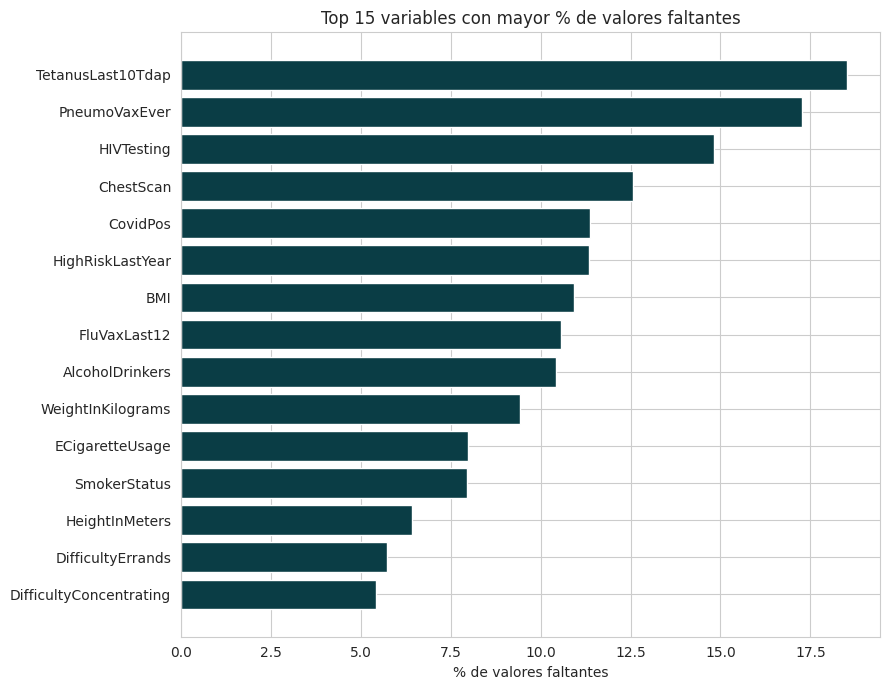

In [110]:
plt.figure(figsize=(9, 7))
top_nulos = tabla_nulos.head(15)
plt.barh(top_nulos.index[::-1], top_nulos['Porcentaje'][::-1], color='#0A3D45')
plt.title('Top 15 variables con mayor % de valores faltantes')
plt.xlabel('% de valores faltantes')
plt.tight_layout()
plt.show()

In [111]:
# 1. Variable objetivo: eliminar filas sin dato
filas_antes = df.shape[0]
df = df.dropna(subset=['HadHeartAttack', 'HadAngina']).reset_index(drop=True)
print('Filas eliminadas por HadHeartAttack/HadAngina nulos:', filas_antes - df.shape[0])

# 2. Numericas continuas: mediana
numericas_continuas = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
                        'HeightInMeters', 'WeightInKilograms', 'BMI']
for col in numericas_continuas:
    df[col] = df[col].fillna(df[col].median())

# 3. Categoricas con missingness bajo/moderado: moda
categoricas_moda = ['Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'PhysicalActivities',
                     'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
                     'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
                     'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking',
                     'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage',
                     'RaceEthnicityCategory', 'AgeCategory', 'AlcoholDrinkers']
for col in categoricas_moda:
    moda = df[col].mode(dropna=True)
    if len(moda) > 0:
        df[col] = df[col].fillna(moda.iloc[0])

# 4. Categoricas de tamizaje opcional: categoria explicita
categoricas_no_informado = ['ChestScan', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
                             'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']
for col in categoricas_no_informado:
    df[col] = df[col].fillna('No informado')

print('\nValores nulos totales despues de la limpieza:', df.isnull().sum().sum())

Filas eliminadas por HadHeartAttack/HadAngina nulos: 6648

Valores nulos totales despues de la limpieza: 0


## 5. Verificación final de la limpieza

Se confirma que el dataset quedó bien limpio antes de seguir con el análisis.


In [112]:
print('=== VERIFICACION FINAL DE LIMPIEZA ===')
print('Filas crudas iniciales      :', 445132)
print('Duplicados exactos quitados :', duplicados_exactos)
print('Valores imposibles marcados :', sum(r['Valores imposibles'] for r in reporte_imposibles))
print('Filas finales limpias       :', df.shape[0])
print('Columnas finales            :', df.shape[1])
print('Nulos totales               :', df.isnull().sum().sum())
print()
for col, (lo, hi) in rangos_validos.items():
    fuera = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col}: valores aun fuera de rango = {fuera}')

=== VERIFICACION FINAL DE LIMPIEZA ===
Filas crudas iniciales      : 445132
Duplicados exactos quitados : 157
Valores imposibles marcados : 10
Filas finales limpias       : 438327
Columnas finales            : 40
Nulos totales               : 0

  PhysicalHealthDays: valores aun fuera de rango = 0
  MentalHealthDays: valores aun fuera de rango = 0
  SleepHours: valores aun fuera de rango = 0
  HeightInMeters: valores aun fuera de rango = 0
  WeightInKilograms: valores aun fuera de rango = 0
  BMI: valores aun fuera de rango = 0


In [113]:
df.to_csv('heart2022_limpio.csv', index=False)
print('Base limpia guardada como heart2022_limpio.csv')

Base limpia guardada como heart2022_limpio.csv


## 6. Variables

**Variable objetivo `HeartDisease`:** se construye como proxy de enfermedad cardíaca a partir de dos antecedentes clínicos: haber tenido un ataque cardíaco (`HadHeartAttack`) o angina (`HadAngina`). Se usa "o" porque ambos son eventos cardiovasculares mayores y cualquiera de los dos indica enfermedad cardíaca presente.

**Variable `AgeMidpoint`:** `AgeCategory` viene en rangos de texto (ej. `"Age 40 to 44"`), lo que impide usarla como número en gráficos de dispersión, correlaciones o el modelo. Se crea el punto medio numérico de cada rango (la categoría "80 or older" se aproxima a 82).


In [114]:
df['HeartDisease'] = ((df['HadHeartAttack'] == 'Yes') | (df['HadAngina'] == 'Yes')).astype(int)

mapa_edad = {
    'Age 18 to 24': 21, 'Age 25 to 29': 27, 'Age 30 to 34': 32, 'Age 35 to 39': 37,
    'Age 40 to 44': 42, 'Age 45 to 49': 47, 'Age 50 to 54': 52, 'Age 55 to 59': 57,
    'Age 60 to 64': 62, 'Age 65 to 69': 67, 'Age 70 to 74': 72, 'Age 75 to 79': 77,
    'Age 80 or older': 82,
}
df['AgeMidpoint'] = df['AgeCategory'].map(mapa_edad)

prevalencia = df['HeartDisease'].value_counts(normalize=True) * 100
print('Prevalencia de HeartDisease (%):')
print(prevalencia.rename({0: 'No', 1: 'Si'}))

Prevalencia de HeartDisease (%):
HeartDisease
No    91.303525
Si     8.696475
Name: proportion, dtype: float64


## 7. Análisis estadístico

Calculamos las medidas de tendencia central, posición y dispersión para las variables numéricas clave.


In [115]:
variables_numericas = ['AgeMidpoint', 'BMI', 'SleepHours', 'PhysicalHealthDays',
                       'MentalHealthDays', 'WeightInKilograms', 'HeightInMeters']

resumen = pd.DataFrame({
    'Media': df[variables_numericas].mean(),
    'Mediana': df[variables_numericas].median(),
    'Moda': df[variables_numericas].mode().iloc[0],
    'Q1 (25%)': df[variables_numericas].quantile(0.25),
    'Q3 (75%)': df[variables_numericas].quantile(0.75),
    'Rango': df[variables_numericas].max() - df[variables_numericas].min(),
    'Varianza': df[variables_numericas].var(),
    'Desv. estandar': df[variables_numericas].std(),
})
resumen['IQR'] = resumen['Q3 (75%)'] - resumen['Q1 (25%)']
resumen['CV (%)'] = (resumen['Desv. estandar'] / resumen['Media']) * 100
resumen.round(2)

,Media,Mediana,Moda,Q1 (25%),Q3 (75%),Rango,Varianza,Desv. estandar,IQR,CV (%)
AgeMidpoint,55.17,57.00,67.00,42.00,67.00,61.00,322.15,17.95,25.00,32.54
BMI,28.40,27.44,27.44,24.41,31.01,87.62,38.28,6.19,6.60,21.78
SleepHours,7.02,7.00,7.00,6.00,8.00,23.00,2.20,1.48,2.00,21.12
PhysicalHealthDays,4.18,0.00,0.00,0.00,3.00,30.00,72.92,8.54,3.00,204.24
MentalHealthDays,4.27,0.00,0.00,0.00,4.00,30.00,68.80,8.29,4.00,194.06
WeightInKilograms,82.85,80.74,80.74,68.04,91.63,269.89,416.31,20.40,23.59,24.63
HeightInMeters,1.70,1.70,1.70,1.63,1.78,1.38,0.01,0.10,0.15,6.09


**Lectura rápida:**
- El **coeficiente de variación (CV)** más alto lo tienen `PhysicalHealthDays` y `MentalHealthDays`: la mayoría de personas reporta 0 días, pero unas pocas reportan hasta 30, generando mucha dispersión relativa a su propia media.
- `BMI` tiene una media 28.4 más alta que su mediana 27.4: son datos con cola hacia la derecha (personas con IMC muy alto que "jalan" la media).


### 7.1 · Asimetría (skewness) y curtosis

In [116]:
forma = pd.DataFrame({
    'Skewness': [stats.skew(df[c].dropna()) for c in variables_numericas],
    'Kurtosis': [stats.kurtosis(df[c].dropna()) for c in variables_numericas],
}, index=variables_numericas)
forma.round(2)

,Skewness,Kurtosis
AgeMidpoint,-0.32,-0.99
BMI,1.52,5.39
SleepHours,0.74,8.68
PhysicalHealthDays,2.25,3.76
MentalHealthDays,2.16,3.56
WeightInKilograms,1.16,3.35
HeightInMeters,0.03,0.36


## 8. Distribución de las variables y pruebas de normalidad

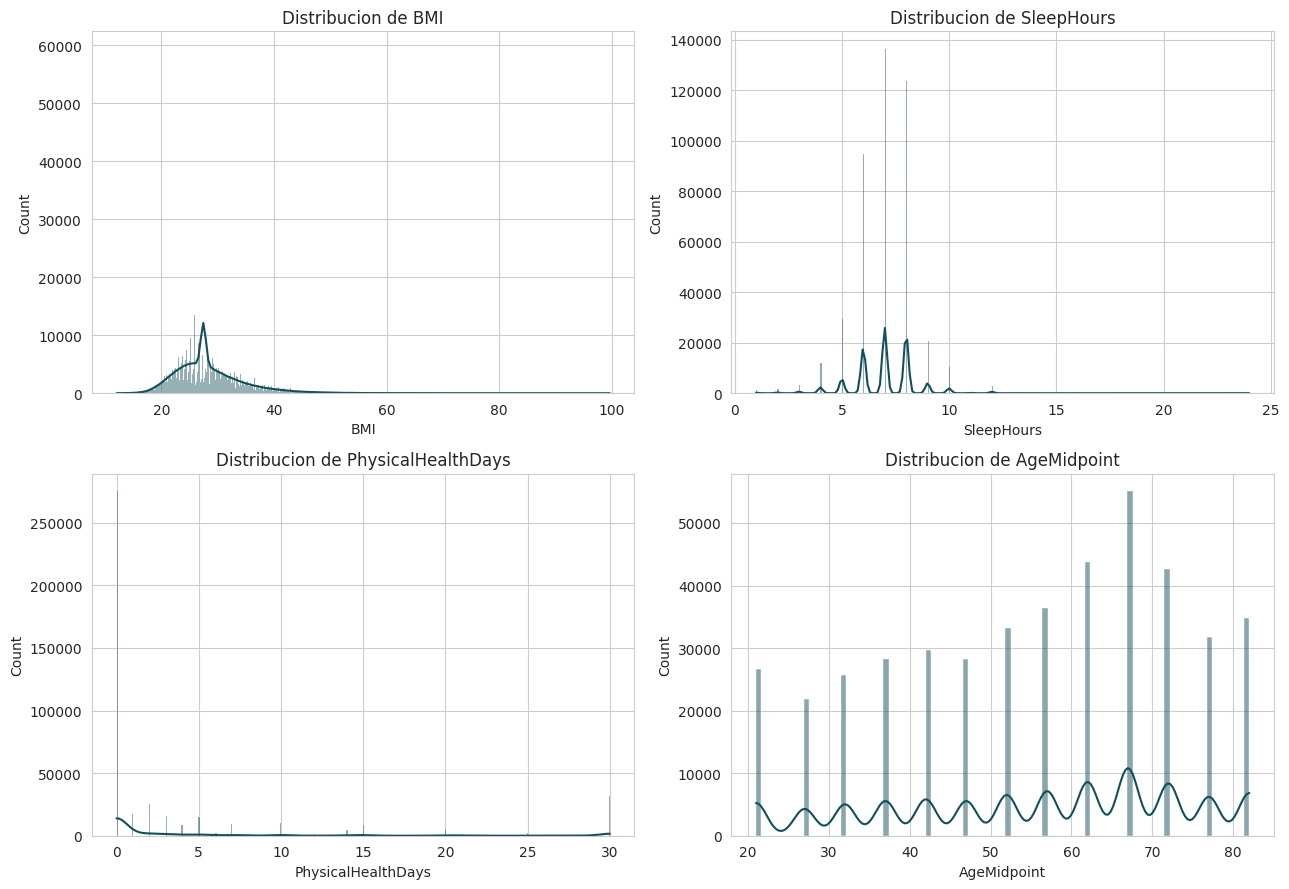

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ['BMI', 'SleepHours', 'PhysicalHealthDays', 'AgeMidpoint']):
    sns.histplot(df[col], kde=True, ax=ax, color='#124F5A')
    ax.set_title(f'Distribucion de {col}')
plt.tight_layout()
plt.show()

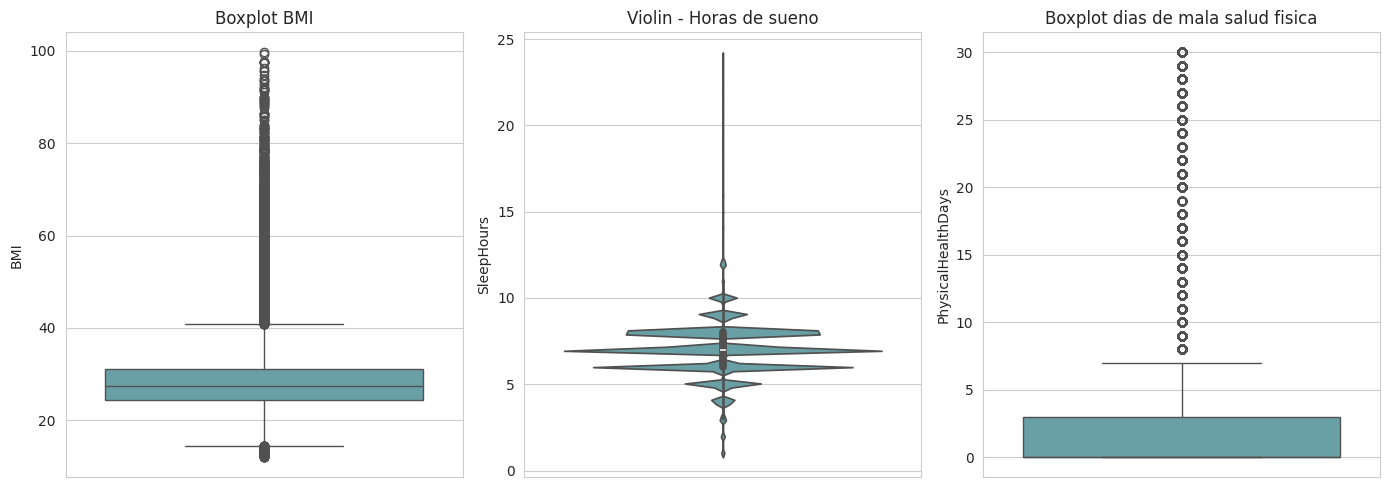

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
sns.boxplot(y=df['BMI'], ax=axes[0], color='#5FA8B0')
axes[0].set_title('Boxplot BMI')
sns.violinplot(y=df['SleepHours'], ax=axes[1], color='#5FA8B0')
axes[1].set_title('Violin - Horas de sueno')
sns.boxplot(y=df['PhysicalHealthDays'], ax=axes[2], color='#5FA8B0')
axes[2].set_title('Boxplot dias de mala salud fisica')
plt.tight_layout()
plt.show()

### 8.1 · Prueba de normalidad y gráfico Q-Q

Con más de 400.000 filas, Shapiro-Wilk no se puede correr sobre todo el dataset (su implementación está pensada para muestras pequeñas y con *n* muy grande casi cualquier prueba rechaza la normalidad por un margen mínimo). Se toma una muestra aleatoria de 4.000 registros para la prueba y se complementa con el gráfico Q-Q sobre toda la variable.


Shapiro-Wilk BMI (muestra n=4000): estadistico=0.8964, p-valor=7.241e-46


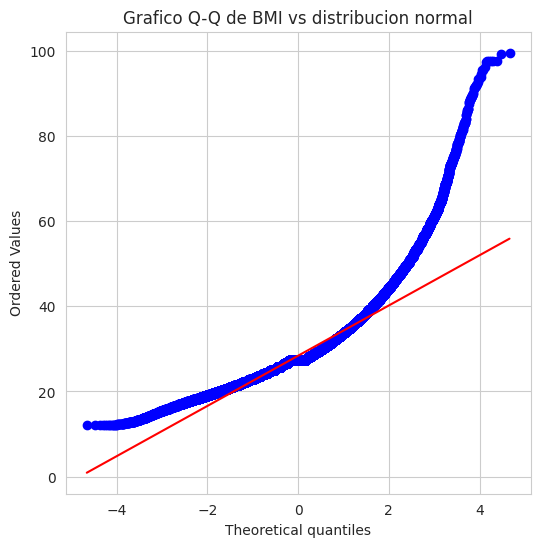

In [119]:
muestra_bmi = df['BMI'].dropna().sample(4000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(muestra_bmi)
print(f'Shapiro-Wilk BMI (muestra n=4000): estadistico={shapiro_stat:.4f}, p-valor={shapiro_p:.4g}')

fig = plt.figure(figsize=(6, 6))
stats.probplot(df['BMI'], dist='norm', plot=plt)
plt.title('Grafico Q-Q de BMI vs distribucion normal')
plt.show()

## 9. Análisis exploratorio de datos (EDA)

### 9.1 · Univariante — variables categóricas clave


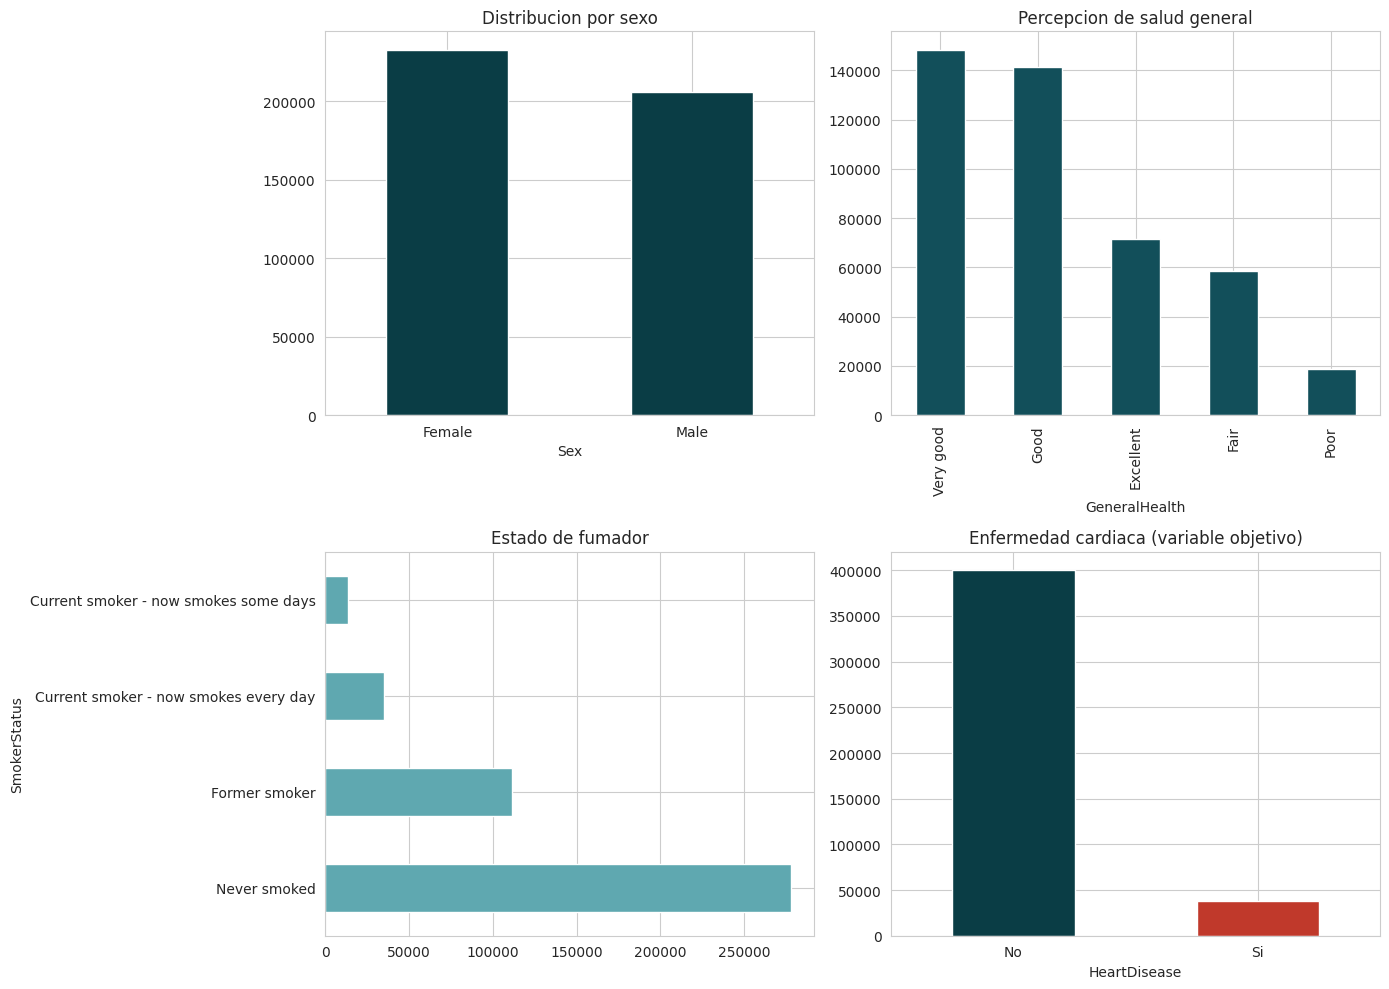

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Sex'].value_counts().plot(kind='bar', ax=axes[0,0], color='#0A3D45')
axes[0,0].set_title('Distribucion por sexo')
axes[0,0].tick_params(axis='x', rotation=0)

df['GeneralHealth'].value_counts().plot(kind='bar', ax=axes[0,1], color='#124F5A')
axes[0,1].set_title('Percepcion de salud general')

df['SmokerStatus'].value_counts().plot(kind='barh', ax=axes[1,0], color='#5FA8B0')
axes[1,0].set_title('Estado de fumador')

df['HeartDisease'].map({0: 'No', 1: 'Si'}).value_counts().plot(kind='bar', ax=axes[1,1], color=['#0A3D45', '#C0392B'])
axes[1,1].set_title('Enfermedad cardiaca (variable objetivo)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 9.2 · Bivariante — enfermedad cardíaca vs. variables demográficas y conductuales

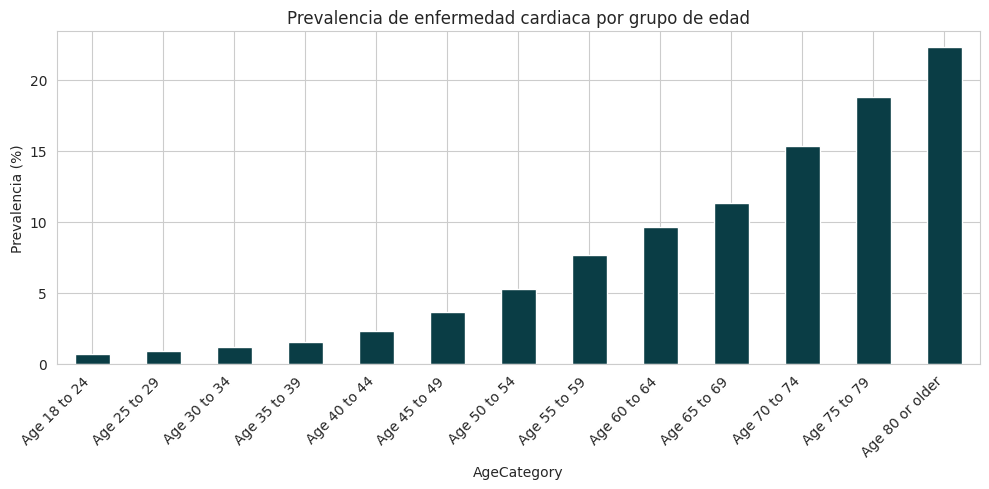

In [121]:
orden_edad = ['Age 18 to 24','Age 25 to 29','Age 30 to 34','Age 35 to 39','Age 40 to 44',
              'Age 45 to 49','Age 50 to 54','Age 55 to 59','Age 60 to 64','Age 65 to 69',
              'Age 70 to 74','Age 75 to 79','Age 80 or older']

prevalencia_edad = (df.groupby('AgeCategory', observed=True)['HeartDisease'].mean() * 100).reindex(orden_edad)

plt.figure(figsize=(10, 5))
prevalencia_edad.plot(kind='bar', color='#0A3D45')
plt.title('Prevalencia de enfermedad cardiaca por grupo de edad')
plt.ylabel('Prevalencia (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Patrón esperado y confirmado:** la prevalencia aumenta de forma casi monótona con la edad, pasando de menos del 1-2 % en los grupos más jóvenes a más del 20 % en el grupo de 80 años o más. La edad es, como es de esperarse clínicamente, uno de los factores de riesgo más fuertes.


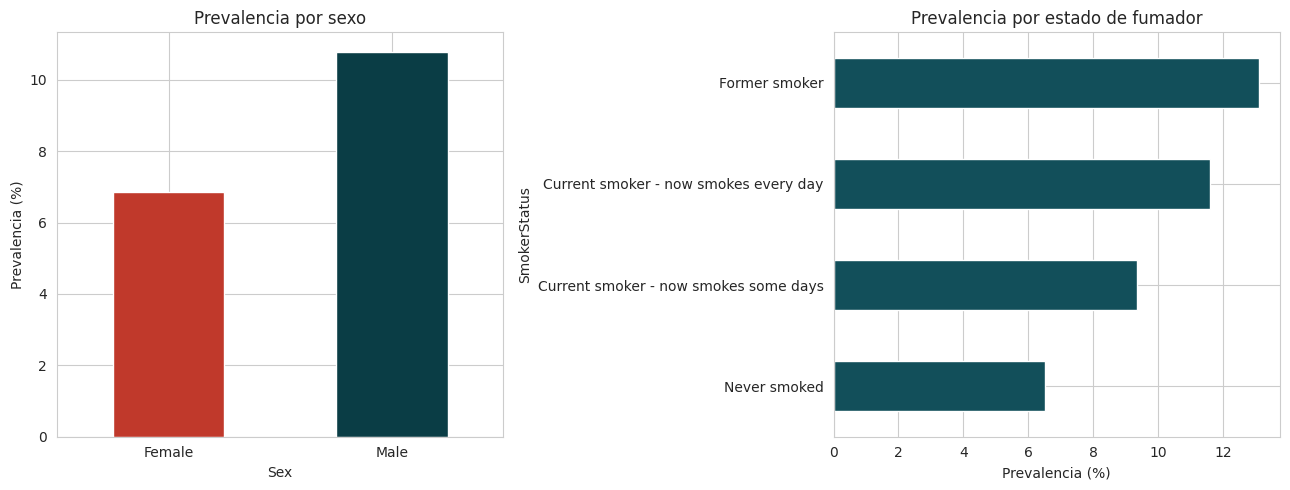

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prev_sexo = df.groupby('Sex')['HeartDisease'].mean() * 100
prev_sexo.plot(kind='bar', ax=axes[0], color=['#C0392B', '#0A3D45'])
axes[0].set_title('Prevalencia por sexo')
axes[0].set_ylabel('Prevalencia (%)')
axes[0].tick_params(axis='x', rotation=0)

prev_fumador = (df.groupby('SmokerStatus')['HeartDisease'].mean() * 100).sort_values()
prev_fumador.plot(kind='barh', ax=axes[1], color='#124F5A')
axes[1].set_title('Prevalencia por estado de fumador')
axes[1].set_xlabel('Prevalencia (%)')

plt.tight_layout()
plt.show()

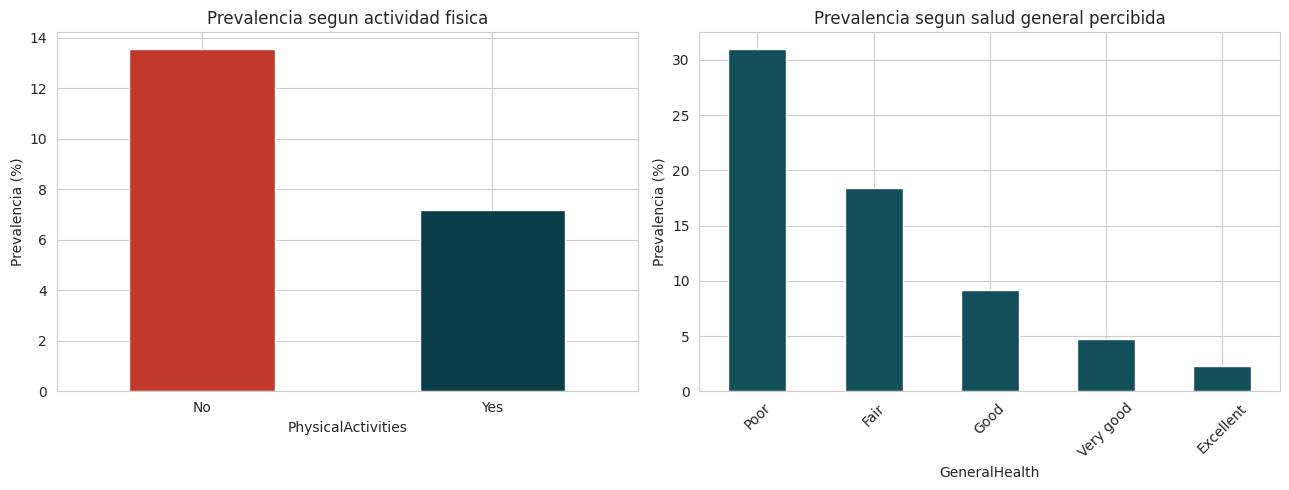

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prev_actividad = df.groupby('PhysicalActivities')['HeartDisease'].mean() * 100
prev_actividad.plot(kind='bar', ax=axes[0], color=['#C0392B', '#0A3D45'])
axes[0].set_title('Prevalencia segun actividad fisica')
axes[0].set_ylabel('Prevalencia (%)')
axes[0].tick_params(axis='x', rotation=0)

prev_salud = (df.groupby('GeneralHealth')['HeartDisease'].mean() * 100).reindex(['Poor','Fair','Good','Very good','Excellent'])
prev_salud.plot(kind='bar', ax=axes[1], color='#124F5A')
axes[1].set_title('Prevalencia segun salud general percibida')
axes[1].set_ylabel('Prevalencia (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

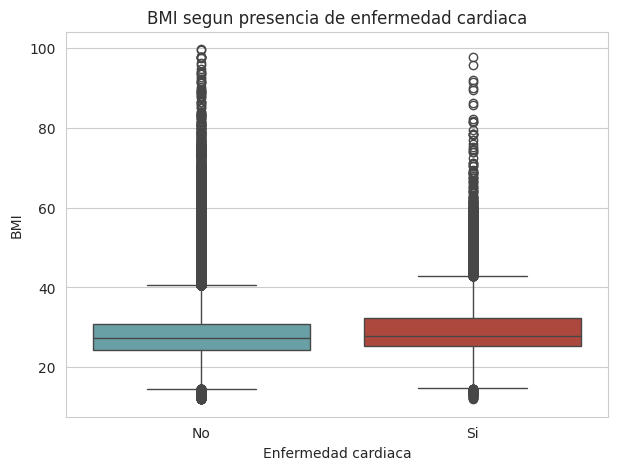

In [124]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='HeartDisease', y='BMI', hue='HeartDisease',
            palette={0: '#5FA8B0', 1: '#C0392B'}, legend=False)
plt.xticks([0, 1], ['No', 'Si'])
plt.title('BMI segun presencia de enfermedad cardiaca')
plt.xlabel('Enfermedad cardiaca')
plt.show()

### 9.3 · Correlación entre variables numéricas

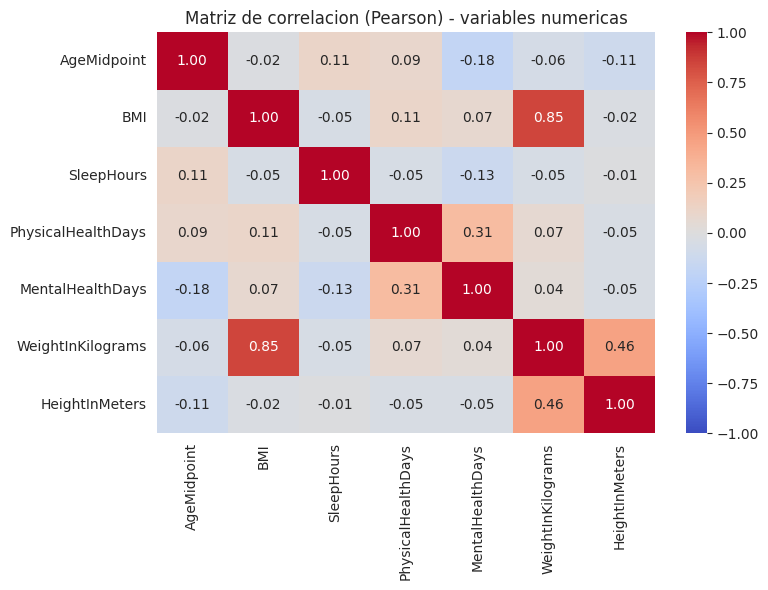

In [125]:
corr = df[variables_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlacion (Pearson) - variables numericas')
plt.tight_layout()
plt.show()

## 10. Análisis estadístico inferencial

Se realizan pruebas de hipótesis para confirmar, con evidencia estadística (no solo visual), qué variables están asociadas con la enfermedad cardíaca.

### 10.1 · Chi-cuadrado de independencia (variables categóricas vs. HeartDisease)

**Hipótesis:**
- H0: la variable categórica es independiente de `HeartDisease`.
- H1: existe asociación entre la variable y `HeartDisease`.

Se usa un nivel de significancia α = 0.05.


In [126]:
variables_categoricas_test = ['Sex', 'SmokerStatus', 'PhysicalActivities', 'GeneralHealth',
                              'HadDiabetes', 'RaceEthnicityCategory']

resultados_chi2 = []
for col in variables_categoricas_test:
    tabla_contingencia = pd.crosstab(df[col], df['HeartDisease'])
    chi2, p, gl, esperado = stats.chi2_contingency(tabla_contingencia)
    resultados_chi2.append({
        'Variable': col,
        'Chi2': round(chi2, 1),
        'gl': gl,
        'p-valor': p,
        'Conclusion': 'Se rechaza H0 (hay asociacion)' if p < 0.05 else 'No se rechaza H0'
    })

tabla_resultados_chi2 = pd.DataFrame(resultados_chi2).sort_values('Chi2', ascending=False)
tabla_resultados_chi2

,Variable,Chi2,gl,p-valor,Conclusion
3,GeneralHealth,25329.3,4,0.000000e+00,Se rechaza H0 (hay asociacion)
4,HadDiabetes,13874.4,3,0.000000e+00,Se rechaza H0 (hay asociacion)
1,SmokerStatus,4759.4,3,0.000000e+00,Se rechaza H0 (hay asociacion)
2,PhysicalActivities,4030.1,1,0.000000e+00,Se rechaza H0 (hay asociacion)
0,Sex,2138.7,1,0.000000e+00,Se rechaza H0 (hay asociacion)
5,RaceEthnicityCategory,1028.4,4,2.550179e-221,Se rechaza H0 (hay asociacion)


### 10.2 · Prueba de Mann-Whitney U (BMI según HeartDisease)

Como se comprobó que `BMI` **no** sigue una distribución normal, la comparación entre los dos grupos (con y sin enfermedad cardíaca) se hace con Mann-Whitney U en vez de una prueba t.

**Hipótesis:**
- H0: la distribución de BMI es igual en ambos grupos.
- H1: la distribución de BMI difiere entre los grupos.


In [127]:
grupo_con_enfermedad = df[df['HeartDisease'] == 1]['BMI']
grupo_sin_enfermedad = df[df['HeartDisease'] == 0]['BMI']

u_stat, p_valor_mw = stats.mannwhitneyu(grupo_con_enfermedad, grupo_sin_enfermedad)

print(f'Mediana BMI - con enfermedad cardiaca : {grupo_con_enfermedad.median():.2f}')
print(f'Mediana BMI - sin enfermedad cardiaca : {grupo_sin_enfermedad.median():.2f}')
print(f'Estadistico U = {u_stat:.3g}')
print(f'p-valor       = {p_valor_mw:.4g}')

Mediana BMI - con enfermedad cardiaca : 27.80
Mediana BMI - sin enfermedad cardiaca : 27.44
Estadistico U = 8.38e+09
p-valor       = 1.097e-224


## 12. Selección del modelo

**Tipo de problema:** clasificación binaria (predecir `HeartDisease`: 0 = No, 1 = Sí).

**Modelos elegidos y por qué:**

| Modelo | Por qué se elige |
|---|---|
| **Regresión Logística** | Es el modelo de referencia para clasificación binaria: rápido, fácil de interpretar (sus coeficientes se traducen directamente en *odds ratios*), y sirve como línea base para saber si un modelo más complejo realmente aporta algo. |
| **Random Forest** | Maneja de forma natural variables numéricas y categóricas mixtas, captura relaciones no lineales e interacciones entre variables (algo que el EDA sugiere que puede estar pasando, dado que las correlaciones lineales simples son débiles) y entrega una medida directa de importancia de variables. |



## 13. Preparación de los datos para el modelo

**Variables predictoras seleccionadas:** se excluyen `HadHeartAttack` y `HadAngina` (fuga de información, ver sección 6), variables administrativas (`State`) y las columnas de tamizaje con categoría "No informado" (para no meterle ruido al modelo con una categoría que representa ausencia de dato, no una condición clínica real).


In [128]:
variables_numericas_modelo = ['AgeMidpoint', 'BMI', 'SleepHours', 'PhysicalHealthDays', 'MentalHealthDays']

variables_categoricas_modelo = ['Sex', 'GeneralHealth', 'SmokerStatus', 'ECigaretteUsage',
                                 'PhysicalActivities', 'AlcoholDrinkers', 'HadDiabetes', 'HadStroke',
                                 'HadAsthma', 'HadKidneyDisease', 'HadArthritis', 'HadDepressiveDisorder',
                                 'HadCOPD', 'HadSkinCancer', 'RaceEthnicityCategory', 'DifficultyWalking']

predictoras = variables_numericas_modelo + variables_categoricas_modelo
datos_modelo = df[predictoras + ['HeartDisease']].dropna()

print('Filas disponibles para el modelo:', datos_modelo.shape[0])
print('Variables predictoras:', len(predictoras))

Filas disponibles para el modelo: 438327
Variables predictoras: 21


In [129]:
X = pd.get_dummies(datos_modelo[predictoras], columns=variables_categoricas_modelo, drop_first=True)
y = datos_modelo['HeartDisease']

print('Dimension de X (tras codificar variables categoricas):', X.shape)

Dimension de X (tras codificar variables categoricas): (438327, 33)


In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
print('Proporcion de positivos en train:', y_train.mean().round(4), '| en test:', y_test.mean().round(4))

# Escalado solo de las variables numericas (necesario para Regresion Logistica; Random Forest no lo necesita)
escalador = StandardScaler()
X_train_esc = X_train.copy()
X_test_esc = X_test.copy()
X_train_esc[variables_numericas_modelo] = escalador.fit_transform(X_train[variables_numericas_modelo])
X_test_esc[variables_numericas_modelo] = escalador.transform(X_test[variables_numericas_modelo])

Entrenamiento: (328745, 33) | Prueba: (109582, 33)
Proporcion de positivos en train: 0.087 | en test: 0.087


## 14. Aplicación de los modelos

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_logistico = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_logistico.fit(X_train_esc, y_train)
                                                                                  #Se demora un poco
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced',
    random_state=42, n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

print('Modelos entrenados correctamente.')

Modelos entrenados correctamente.


## 15. Evaluación de los modelos

In [132]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

resultados_modelos = []
predicciones = {}

for nombre, modelo, X_te in [('Regresion Logistica', modelo_logistico, X_test_esc),
                             ('Random Forest', modelo_rf, X_test)]:
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    predicciones[nombre] = (y_pred, y_proba)
    resultados_modelos.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
    })

tabla_metricas = pd.DataFrame(resultados_modelos).round(3)
tabla_metricas

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Regresion Logistica,0.750,0.226,0.773,0.349,0.839
1,Random Forest,0.753,0.227,0.766,0.351,0.836


**Cómo leer estas métricas:**
- **Accuracy** (~75 %) por sí sola es poco informativa aquí por el desbalance de clases.
- **Recall** (~77 %) es la métrica más importante en este problema: de todas las personas que sí tienen enfermedad cardíaca, el modelo logra identificar a cerca del 77 %. En un contexto de salud pública, es preferible un falso positivo (enviar a alguien sano a un chequeo de más) que un falso negativo (no detectar a alguien enfermo).
- **Precision** más baja (~23 %) es el costo de priorizar el recall con `class_weight='balanced'`: de cada 10 personas que el modelo marca como "en riesgo", cerca de 2-3 realmente tienen la enfermedad. Es un trade-off consciente, no un error del modelo.
- **AUC-ROC** (~0.84) indica que el modelo distingue razonablemente bien entre las dos clases, muy por encima de 0.5 (que sería equivalente a adivinar al azar).


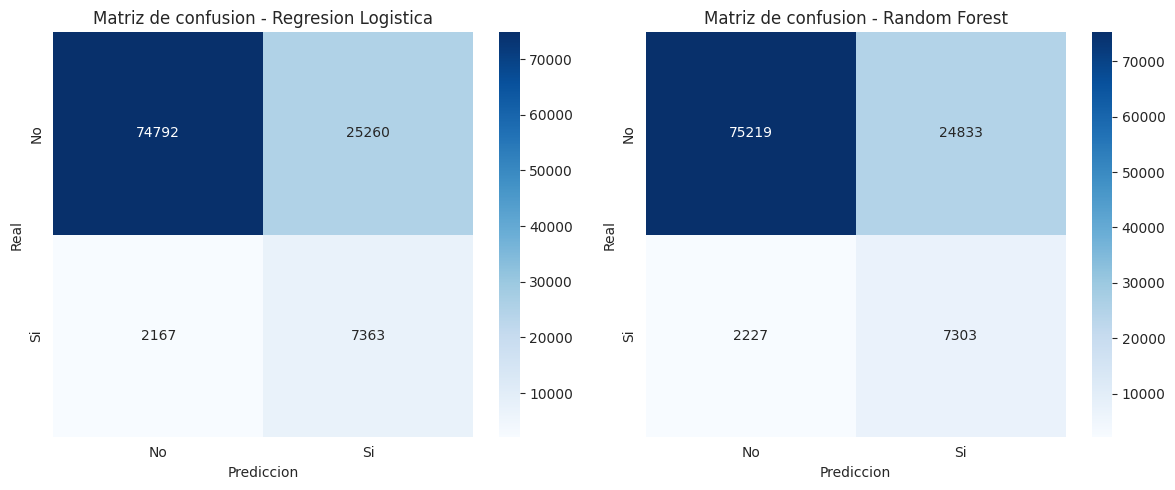

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, (y_pred, _)) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Si'], yticklabels=['No', 'Si'])
    ax.set_title(f'Matriz de confusion - {nombre}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

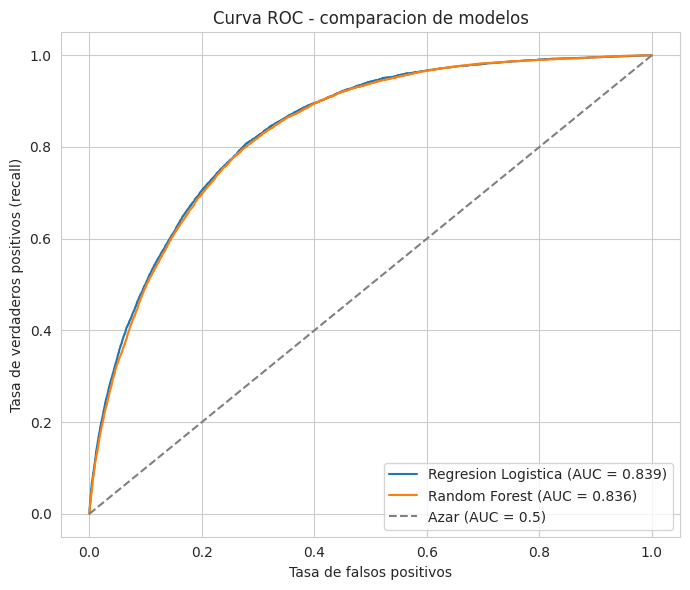

In [134]:
plt.figure(figsize=(7, 6))
for nombre, (_, y_proba) in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curva ROC - comparacion de modelos')
plt.legend()
plt.tight_layout()
plt.show()

### 15.1 · Interpretación de los factores más importantes

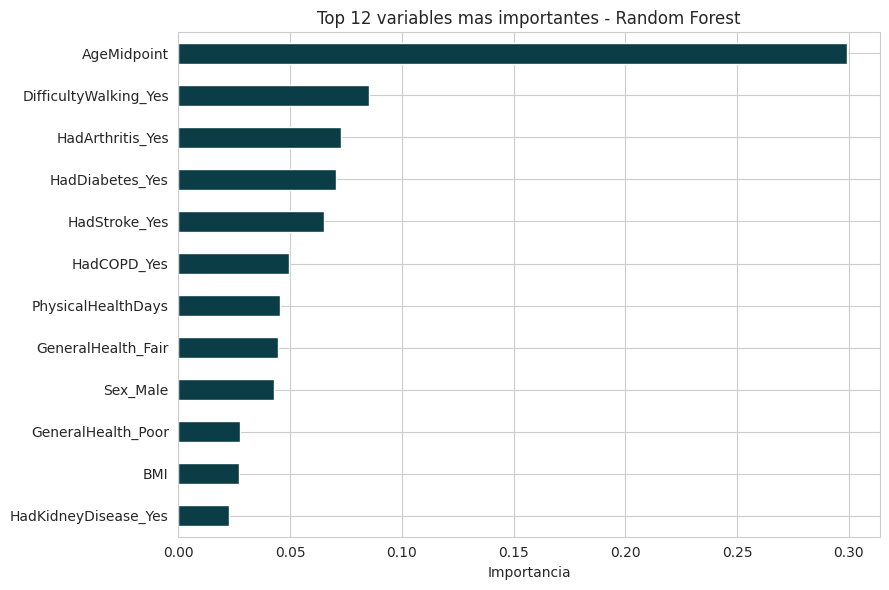

In [135]:
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importancias_rf.head(12).sort_values().plot(kind='barh', color='#0A3D45')
plt.title('Top 12 variables mas importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [136]:
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X.columns)
odds_ratios = np.exp(coeficientes).sort_values(ascending=False)

print('Variables que MAS aumentan la probabilidad de enfermedad cardiaca (odds ratio > 1):')
print(odds_ratios.head(8).round(2))

print('\nVariables que MAS reducen la probabilidad de enfermedad cardiaca (odds ratio < 1):')
print(odds_ratios.tail(8).round(2))

Variables que MAS aumentan la probabilidad de enfermedad cardiaca (odds ratio > 1):
GeneralHealth_Poor      5.08
GeneralHealth_Fair      4.02
HadStroke_Yes           3.21
AgeMidpoint             2.70
GeneralHealth_Good      2.56
Sex_Male                2.21
HadKidneyDisease_Yes    1.80
HadCOPD_Yes             1.68
dtype: float64

Variables que MAS reducen la probabilidad de enfermedad cardiaca (odds ratio < 1):
MentalHealthDays                                      1.02
ECigaretteUsage_Use them every day                    1.00
ECigaretteUsage_Not at all (right now)                1.00
SleepHours                                            0.95
SmokerStatus_Current smoker - now smokes some days    0.94
SmokerStatus_Former smoker                            0.90
AlcoholDrinkers_Yes                                   0.88
SmokerStatus_Never smoked                             0.72
dtype: float64


---
### Anexo: descarga de la base limpia


In [137]:
from google.colab import files
files.download('heart2022_limpio.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>